In [ ]:
# Cell 1 — Imports and loader
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.insert(0, '..')

RESULTS_DIR     = ['../03_FedGen/results','../02_FedAvg/results']
ALPHA_SWEEP     = [0.5, 1.0, 5.0]
SEEDS           = [42, 123, 7]
CENTRALIZED_AUC = 0.658


VARIANTS = {
    'fedavg_full':    {'label': 'FedAvg (full)',    'color': '#4C72B0', 'ls': '-'},
    'fedgen_full':    {'label': 'FedGen (full)',    'color': '#DD8452', 'ls': '-'},
    'fedavg_partial': {'label': 'FedAvg (partial)', 'color': '#4C72B0', 'ls': '--'},
    'fedgen_partial': {'label': 'FedGen (partial)', 'color': '#DD8452', 'ls': '--'},
}

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size': 11,
})


def load_results(results_dir, alpha_sweep, seeds, variants):
    """
    Returns nested dict: results[alpha][variant] = {
        'test_aucs':     list of floats (one per seed),
        'per_client':    list of dicts (one per seed),
        'histories':     list of history lists (one per seed),
        'cumul_mbs':     list of MB lists (one per seed),
    }
    """
    data = {}
    for alpha in alpha_sweep:
        data[alpha] = {}
        for variant in variants:
            aucs, per_client, histories, mbs = [], [], [], []
            for results_dir in RESULTS_DIR:
                for seed in seeds:
                    if results_dir.endswith('FedGen'):
                        p = os.path.join(results_dir, f'alpha_{alpha}',
                                        f'seed_{seed}', f'{variant}.json')
                        if os.path.exists(p):
                            r = json.load(open(p))
                            aucs.append(r['test_auc'])
                            per_client.append(r['per_client'])
                            histories.append(r['history'])
                            mbs.append(r['cumul_mb'])
                        else:
                            print(f'Warning: Missing file {p}')    
            data[alpha][variant] = {
                'test_aucs':  aucs,
                'per_client': per_client,
                'histories':  histories,
                'cumul_mbs':  mbs,
            }
    return data

results = load_results(RESULTS_DIR, ALPHA_SWEEP, SEEDS, VARIANTS)
print('Results loaded.')

Results loaded.


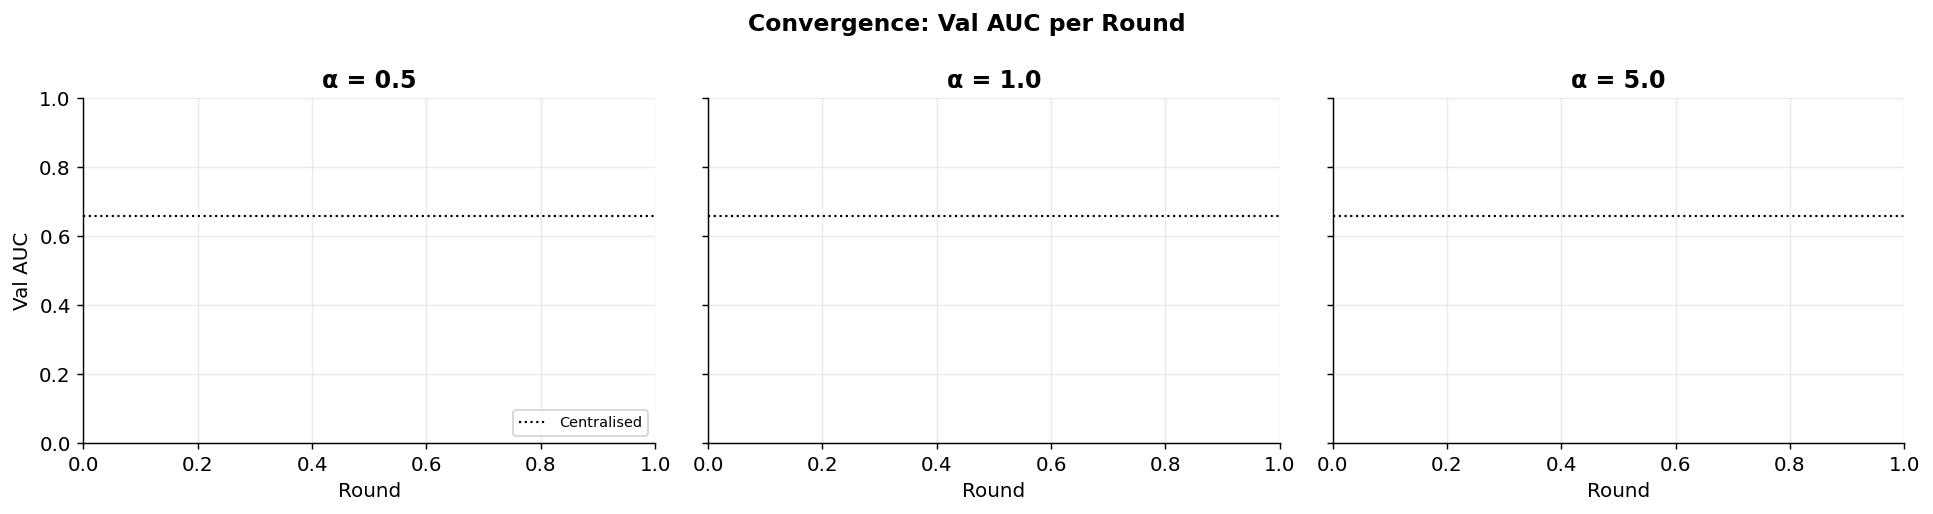

In [10]:
# Cell 2 — Figure 1: AUC vs Rounds (convergence curves)
# One subplot per alpha, all four variants + centralized reference line.

fig, axes = plt.subplots(1, len(ALPHA_SWEEP), figsize=(5 * len(ALPHA_SWEEP), 4),
                         sharey=True)
fig.suptitle('Convergence: Val AUC per Round', fontweight='bold', fontsize=13)

for ax, alpha in zip(axes, ALPHA_SWEEP):
    ax.axhline(CENTRALIZED_AUC, color='black', linestyle=':', linewidth=1.2,
               label='Centralised')

    for vname, vinfo in VARIANTS.items():
        d = results[alpha][vname]
        if not d['histories']:
            continue
        # Pad shorter runs to the same length, then mean ± std
        max_len = max(len(h) for h in d['histories'])
        padded  = [h + [h[-1]] * (max_len - len(h)) for h in d['histories']]
        vals    = np.array([[step['val'] for step in h] for h in padded])
        mean, std = vals.mean(0), vals.std(0)

        rounds = range(1, max_len + 1)
        ax.plot(rounds, mean, color=vinfo['color'], ls=vinfo['ls'],
                linewidth=2, label=vinfo['label'])
        ax.fill_between(rounds, mean - std, mean + std,
                        color=vinfo['color'], alpha=0.15)

    ax.set_title(f'α = {alpha}', fontweight='bold')
    ax.set_xlabel('Round')
    if ax == axes[0]:
        ax.set_ylabel('Val AUC')
        ax.legend(fontsize=8, loc='lower right')
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('figures/fig1_convergence_rounds.png', bbox_inches='tight')
plt.show()

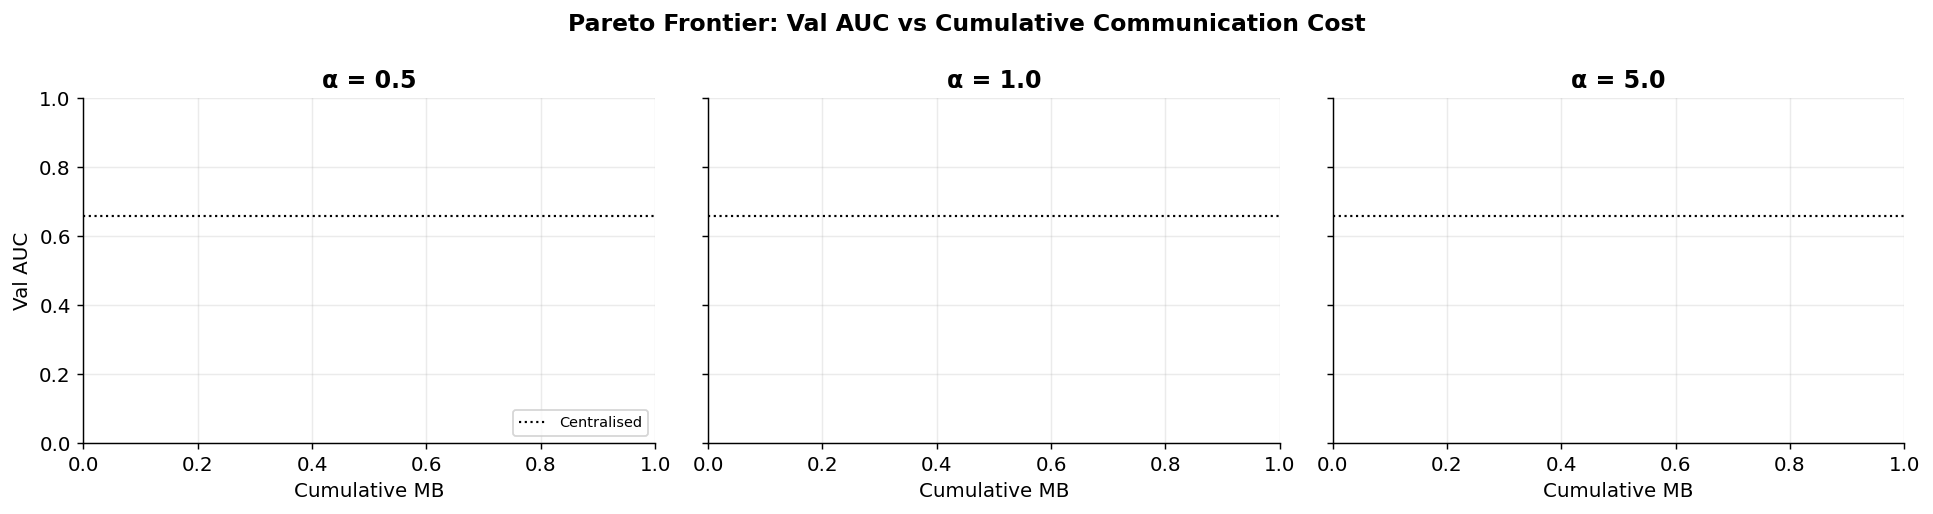

In [11]:
# Cell 3 — Figure 2: Pareto Frontier — AUC vs Cumulative MB
# This is the central thesis result.

fig, axes = plt.subplots(1, len(ALPHA_SWEEP), figsize=(5 * len(ALPHA_SWEEP), 4),
                         sharey=True)
fig.suptitle('Pareto Frontier: Val AUC vs Cumulative Communication Cost',
             fontweight='bold', fontsize=13)

for ax, alpha in zip(axes, ALPHA_SWEEP):
    ax.axhline(CENTRALIZED_AUC, color='black', linestyle=':', linewidth=1.2,
               label='Centralised')

    for vname, vinfo in VARIANTS.items():
        d = results[alpha][vname]
        if not d['histories']:
            continue
        max_len = max(len(h) for h in d['histories'])
        padded_h  = [h + [h[-1]] * (max_len - len(h)) for h in d['histories']]
        padded_mb = [m + [m[-1]] * (max_len - len(m)) for m in d['cumul_mbs']]
        vals = np.array([[step['val'] for step in h] for h in padded_h])
        mbs  = np.array(padded_mb)
        mean_v, std_v = vals.mean(0), vals.std(0)
        mean_mb       = mbs.mean(0)

        ax.plot(mean_mb, mean_v, color=vinfo['color'], ls=vinfo['ls'],
                linewidth=2, label=vinfo['label'])
        ax.fill_between(mean_mb, mean_v - std_v, mean_v + std_v,
                        color=vinfo['color'], alpha=0.15)

    ax.set_title(f'α = {alpha}', fontweight='bold')
    ax.set_xlabel('Cumulative MB')
    if ax == axes[0]:
        ax.set_ylabel('Val AUC')
        ax.legend(fontsize=8, loc='lower right')
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('figures/fig2_pareto_frontier.png', bbox_inches='tight')
plt.show()

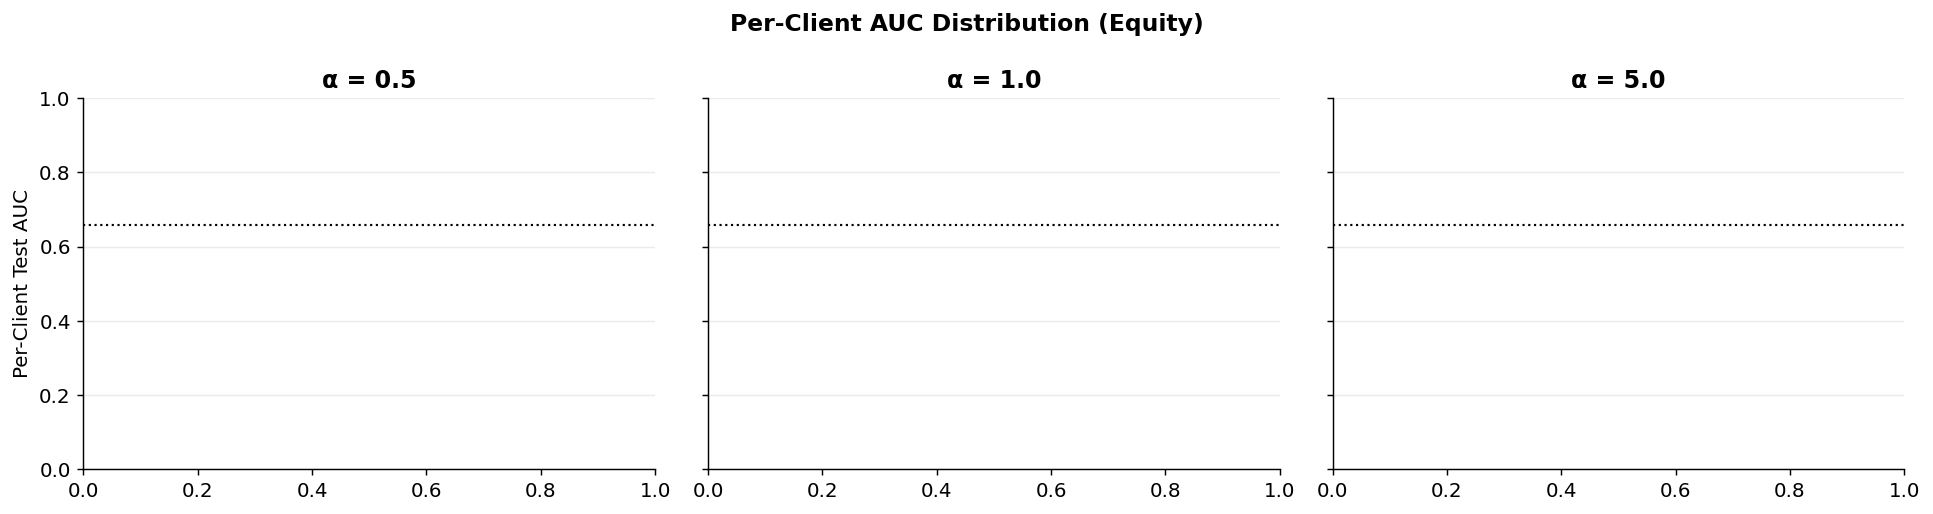

In [12]:
# Cell 4 — Figure 3: Per-Client AUC (Equity)
# Boxplot of per-client AUC across seeds for each variant and alpha.

fig, axes = plt.subplots(1, len(ALPHA_SWEEP), figsize=(5 * len(ALPHA_SWEEP), 4),
                         sharey=True)
fig.suptitle('Per-Client AUC Distribution (Equity)', fontweight='bold', fontsize=13)

for ax, alpha in zip(axes, ALPHA_SWEEP):
    box_data  = []
    box_labels = []
    box_colors = []

    for vname, vinfo in VARIANTS.items():
        d = results[alpha][vname]
        # Collect all per-client AUCs across all seeds
        all_aucs = []
        for pc in d['per_client']:
            all_aucs.extend(pc.values())
        if all_aucs:
            box_data.append(all_aucs)
            box_labels.append(vinfo['label'])
            box_colors.append(vinfo['color'])

    if box_data:
        bp = ax.boxplot(box_data, patch_artist=True,
                        medianprops={'color': 'black', 'linewidth': 2})
        for patch, color in zip(bp['boxes'], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set_xticklabels(box_labels, rotation=20, ha='right', fontsize=8)

    ax.axhline(CENTRALIZED_AUC, color='black', linestyle=':', linewidth=1.2)
    ax.set_title(f'α = {alpha}', fontweight='bold')
    if ax == axes[0]:
        ax.set_ylabel('Per-Client Test AUC')
    ax.grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig('figures/fig3_per_client_auc.png', bbox_inches='tight')
plt.show()

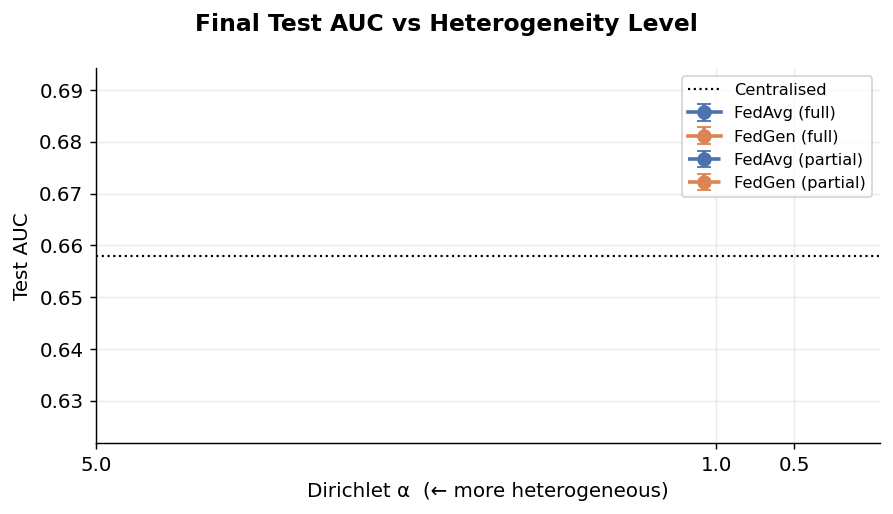

In [13]:
# Cell 5 — Figure 4: AUC vs Alpha (how heterogeneity affects each variant)

fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle('Final Test AUC vs Heterogeneity Level', fontweight='bold', fontsize=13)

ax.axhline(CENTRALIZED_AUC, color='black', linestyle=':', linewidth=1.2,
           label='Centralised')

for vname, vinfo in VARIANTS.items():
    means, stds = [], []
    for alpha in ALPHA_SWEEP:
        aucs = results[alpha][vname]['test_aucs']
        means.append(np.mean(aucs) if aucs else np.nan)
        stds.append(np.std(aucs)   if aucs else 0)

    ax.errorbar(ALPHA_SWEEP, means, yerr=stds,
                color=vinfo['color'], ls=vinfo['ls'],
                linewidth=2, marker='o', markersize=7,
                capsize=4, label=vinfo['label'])

ax.set_xlabel('Dirichlet α  (← more heterogeneous)')
ax.set_ylabel('Test AUC')
ax.set_xticks(ALPHA_SWEEP)
ax.invert_xaxis()
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('figures/fig4_auc_vs_alpha.png', bbox_inches='tight')
plt.show()

In [14]:
# Cell 6 — Summary table (for thesis)

import pandas as pd

rows = []
for alpha in ALPHA_SWEEP:
    for vname, vinfo in VARIANTS.items():
        aucs = results[alpha][vname]['test_aucs']
        if aucs:
            rows.append({
                'α':       alpha,
                'Variant': vinfo['label'],
                'Mean AUC': round(np.mean(aucs), 4),
                'Std':      round(np.std(aucs),  4),
                'Rounds':   np.mean([len(h) for h in results[alpha][vname]['histories']]),
                'MB':       round(np.mean([m[-1] for m in results[alpha][vname]['cumul_mbs']]), 1),
            })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

Empty DataFrame
Columns: []
Index: []
